# Time Series

This notebook is a hands-on practice to get familiar with **time series analysis** and the fundamental concepts that make it different from classical machine learning on tabular data.

Dataset used from:  
- https://www.kaggle.com/datasets/shenba/time-series-datasets
- https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv

---

## What is a Time Series?

A **time series** is a sequence of observations recorded over time, where:

- The **order of observations matters**
- The **past influences the future**
- There is often **autocorrelation** between values
- Data commonly contains **trend**, **seasonality**, and **noise**
- The data is often **non-stationary**

A time series can be represented as:

\[
Y(t) = Trend(t) + Seasonality(t) + Noise(t)
\]

Examples of time series:
- number of sales per month
- weather conditions
- unemployment rate

---

## Use cases of time series analysis:

Time series analysis is an important component in various fields.

- **Business analytics**: forecasting sales, website traffic, user activity.
- **Marketing**: forecasting demand for products and services, planning advertising campaigns.
- **Financial sector**: forecasting stock prices, analyzing market trends.
- **Logistics and inventory management**: forecasting demand for goods, planning supplies.
- **Social sciences**: analyzing trends in social networks, forecasting population.

---

## Key Concepts to Learn

**Trend**
Long-term increase or decrease in the data.

**Seasonality**
Regular repeating patterns over fixed time intervals.

**Noise (Residual)**
Random variation that cannot be explained by trend or seasonality.

**Stationarity**
A stationary series has constant statistical properties over time (mean, variance, autocorrelation).

Many classical time series models (like ARIMA) require stationarity.

**Autocorrelation**
Correlation of the series with its past values.


## Imports & Loads Data

In [9]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict

from mlpeople.time_series.io import read_df, read_shampoo_df


# styles setup
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 18,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
passengers_df = read_df("airline-passengers.csv")
passengers_df.head()

,Passengers
Date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [12]:
temperature_df = read_df("daily-minimum-temperatures-in-me.csv", datetime_col="Date")
temperature_df.head()

,Daily minimum temperatures
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [13]:
electric_df = read_df("Electric_Production.csv", datetime_col="DATE")
electric_df.head()

,IPG2211A2N
Date,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


In [14]:
beer_df = read_df("monthly-beer-production-in-austr.csv", datetime_col="Month")
beer_df.head()

,Monthly beer production
Date,
1956-01-01,93.2
1956-02-01,96.0
1956-03-01,95.2
1956-04-01,77.1
1956-05-01,70.9


In [15]:
shampoo_df = read_shampoo_df("sales-of-shampoo-over-a-three-ye.csv")
shampoo_df.head()

,Sales of shampoo over a three year period
Date,
1901-01-01,266.0
1901-02-01,145.9
1901-03-01,183.1
1901-04-01,119.3
1901-05-01,180.3


## Time Series Visualizations

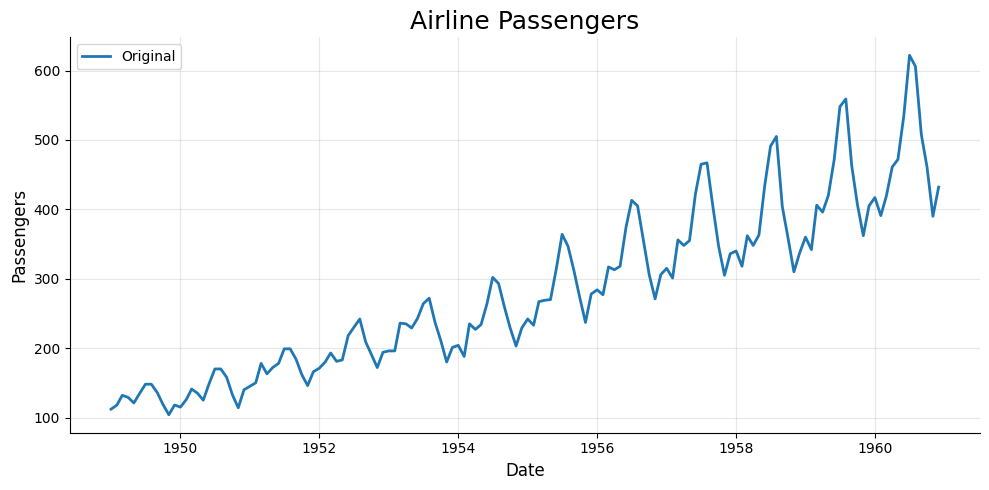

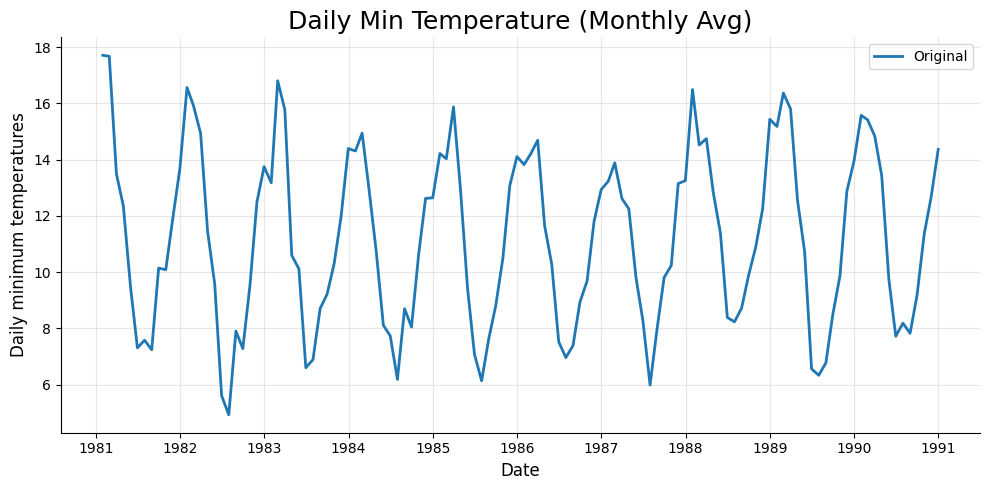

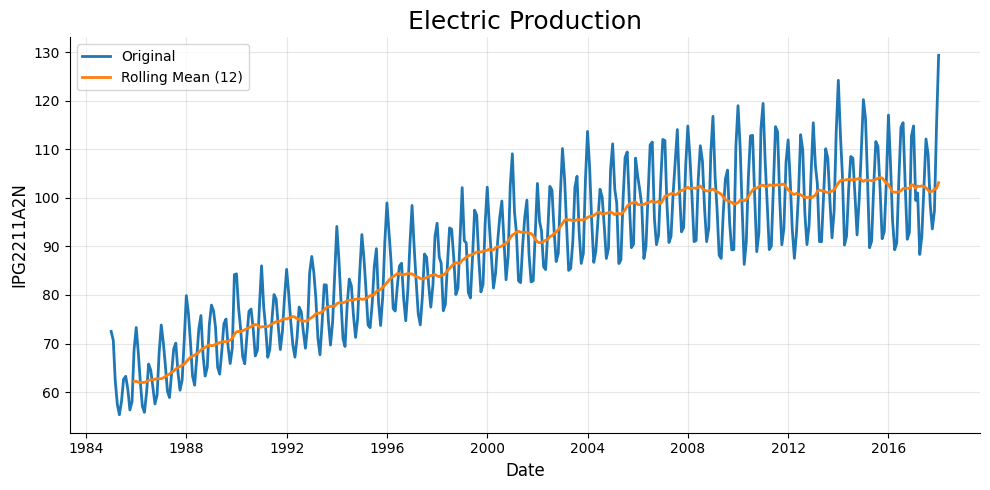

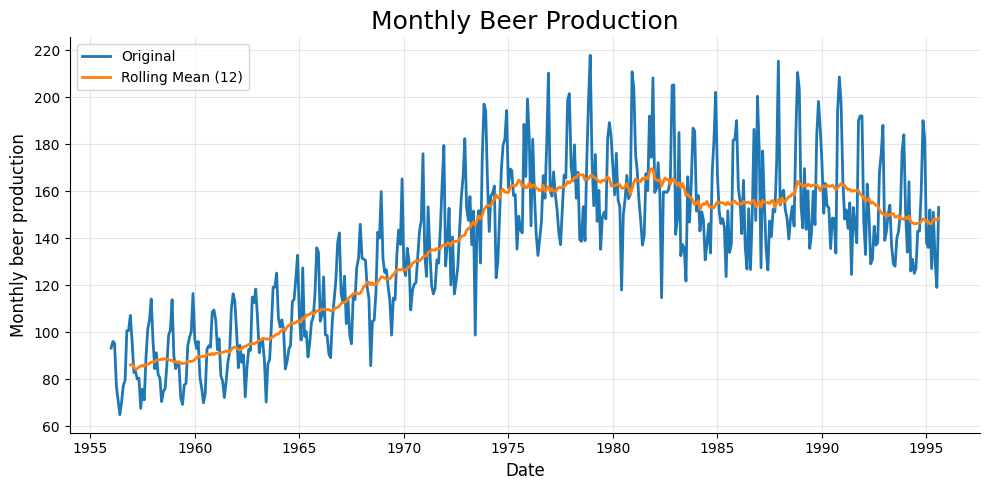

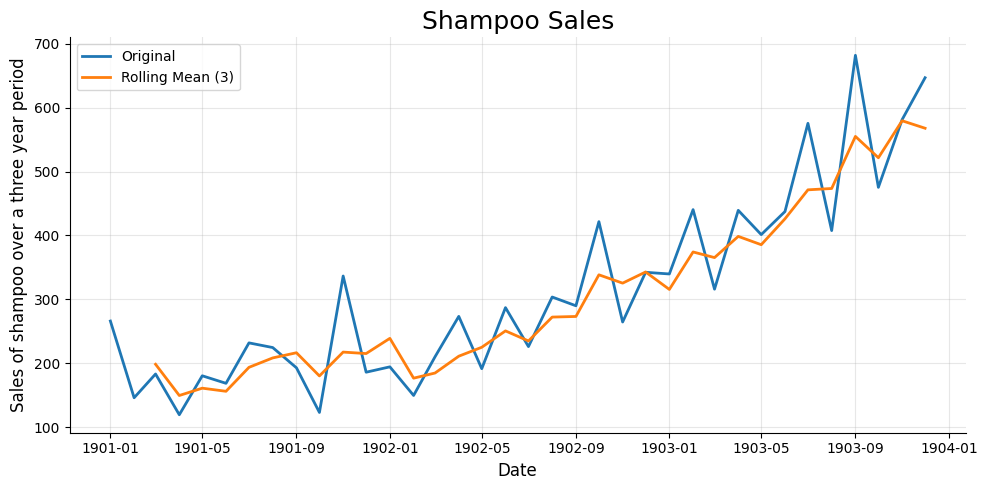

In [16]:
from mlpeople.time_series.plotting import plot_ts

plot_ts(passengers_df, "Passengers", title="Airline Passengers")

plot_ts(temperature_df, "Daily minimum temperatures", title="Daily Min Temperature (Monthly Avg)", resample="ME")

plot_ts(electric_df, "IPG2211A2N", title="Electric Production", rolling=12)

plot_ts(beer_df, "Monthly beer production", title="Monthly Beer Production", rolling=12)

plot_ts(shampoo_df, "Sales of shampoo over a three year period",
        title="Shampoo Sales", rolling=3)

## Time Series Basics

**Information Content**
Time series data contains rich information, typically broken down into:

- **Trend**: long-term changes over time  
- **Seasonality**: repeating patterns at fixed intervals  
- **Cyclicality**: irregular long-term fluctuations (e.g., economic cycles)  
- **Residuals**: unpredictable random variations  

---

**Forecasting from History**
One key task is predicting future values using historical patterns.  

- **Temporal dependence**: current values depend on past values → train on older data, validate on newer  
- **Autocorrelation**: values often correlate with previous points (e.g., weather today similar to yesterday)  

---

### Core Components

**Trend**
Represents long-term changes in the **average** level of the series:

- **Upward trend**: general increase over time  
- **Downward trend**: general decrease over time  
- **Stable trend**: values remain roughly constant  

**Seasonality**
Regular, repeating patterns over time (e.g., daily, weekly, monthly, yearly).

- **Example**: ice cream or beer sales increase in summer, decrease in winter  
- Can be **additive** (added to trend) or **multiplicative** (scaled by trend)  

**Cyclicality**
Long-term, irregular fluctuations not tied to fixed intervals.

- **Example**: economic booms and recessions  
- Harder to detect than seasonality, usually requires manual analysis  

**Residuals**
Random noise not explained by trend, seasonality, or cyclicality.  

> Extracting these components is called **decomposition**.

## Additive and Multiplicative Models

To model trend, seasonality, cyclicality, and residuals in a time series, two main approaches are used: **additive** and **multiplicative**.

---

### Additive Model

The **additive model** assumes that all components **add together**.  
Best for series where the **seasonal amplitude remains constant** regardless of trend level.

**Formula**:  
$$ Y_t = T_t + S_t + C_t + E_t $$

- $Y_t$ — observed value at time $t$  
- $T_t$ — trend component  
- $S_t$ — seasonal component  
- $C_t$ — cyclic component  
- $E_t$ — residual/noise  

**Example**:  
Monthly coffee sales with a steady upward trend, seasonal peaks in winter and summer, economic cycles, and random events. In additive form, all components simply **sum together**.

**Visualization**:  
- Trend — smooth overall line  
- Seasonality — wavy line added to trend  
- Cyclicality — long-term fluctuations around trend  
- Residuals — random variations around trend + seasonality  

---

### Multiplicative Model

The **multiplicative model** assumes that all components **multiply**.  
Best for series where **seasonal amplitude grows with trend**.

**Formula**:  
$$ Y_t = T_t \times S_t \times C_t \times E_t $$

- Components same as above  
- Useful when seasonal effects scale with level  

**Example**:  
Sales that rise over time with proportionally larger seasonal swings. Multiplicative decomposition highlights these proportional effects.

> Next step: we can manually decompose a time series first using the additive model.

### Manually decompose time series

Use customly implemented functions logic to decompose and visualize time serieses

In [20]:
from mlpeople.time_series.decomposition import create_ts_additive_df, create_ts_multiplicative_df
from mlpeople.time_series.plotting import plot_ts_df_decomposition, plot_ts_trend, plot_ts_decompose

In [21]:
passengers_df_add = create_ts_additive_df(passengers_df)
passengers_df_add

,Passengers,trend,detrended,season_key,seasonality,resid
Date,,,,,,
1949-01-01,112,127.857143,-15.857143,1,-29.577839,13.720696
1949-02-01,118,130.375000,-12.375000,2,-39.556891,27.181891
1949-03-01,132,131.000000,1.000000,3,-3.711538,4.711538
1949-04-01,129,129.800000,-0.800000,4,-6.432051,5.632051
1949-05-01,121,127.454545,-6.454545,5,-1.178904,-5.275641
...,...,...,...,...,...,...
1960-08-01,606,481.545455,124.454545,8,69.569930,54.884615
1960-09-01,508,490.600000,17.400000,9,15.783333,1.616667
1960-10-01,461,498.555556,-37.555556,10,-22.334758,-15.220798


In [22]:
passengers_df_mult = create_ts_multiplicative_df(passengers_df)
passengers_df_mult

,Passengers,trend,detrended,season_key,seasonality,resid
Date,,,,,,
1949-01-01,112,127.857143,0.875978,1,0.891195,0.982925
1949-02-01,118,130.375000,0.905081,2,0.870627,1.039574
1949-03-01,132,131.000000,1.007634,3,1.002014,1.005609
1949-04-01,129,129.800000,0.993837,4,0.981623,1.012442
1949-05-01,121,127.454545,0.949358,5,0.991442,0.957553
...,...,...,...,...,...,...
1960-08-01,606,481.545455,1.258448,8,1.230589,1.022639
1960-09-01,508,490.600000,1.035467,9,1.055052,0.981436
1960-10-01,461,498.555556,0.924671,10,0.921404,1.003546


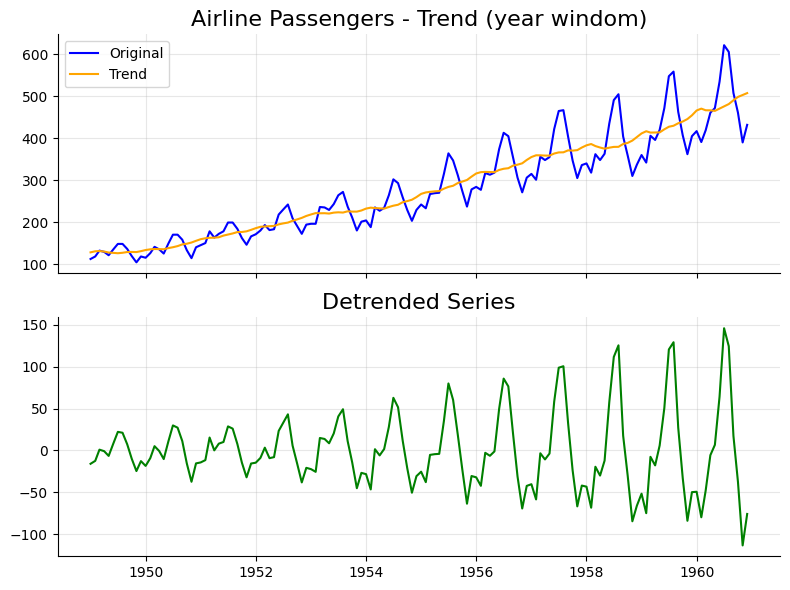

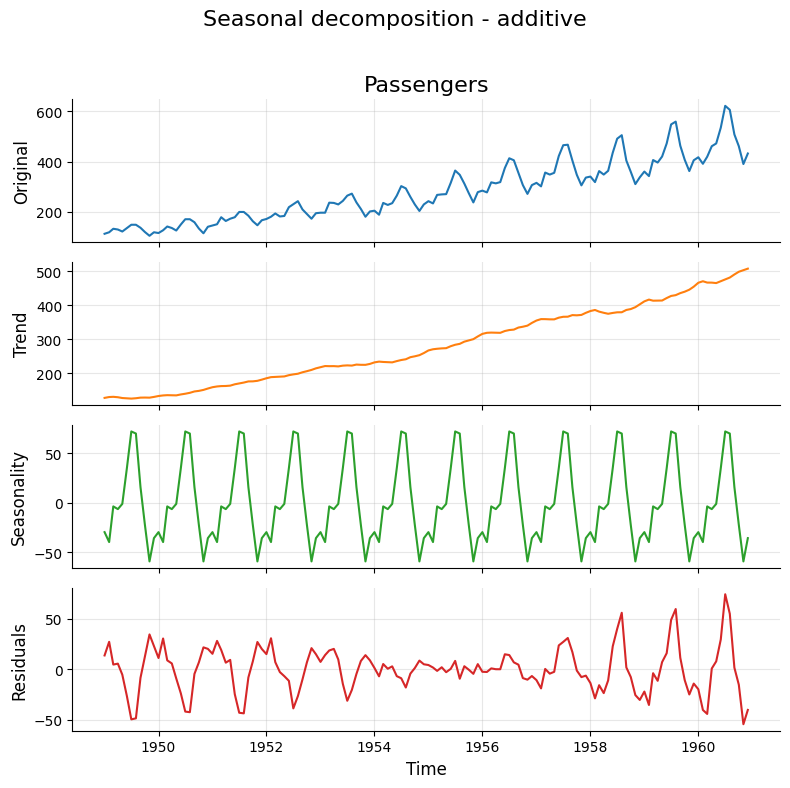

In [23]:
plot_ts_df_decomposition(
    passengers_df_add,
    title_trend="Airline Passengers - Trend (year windom)",
    title_decompose="Seasonal decomposition - additive",
)

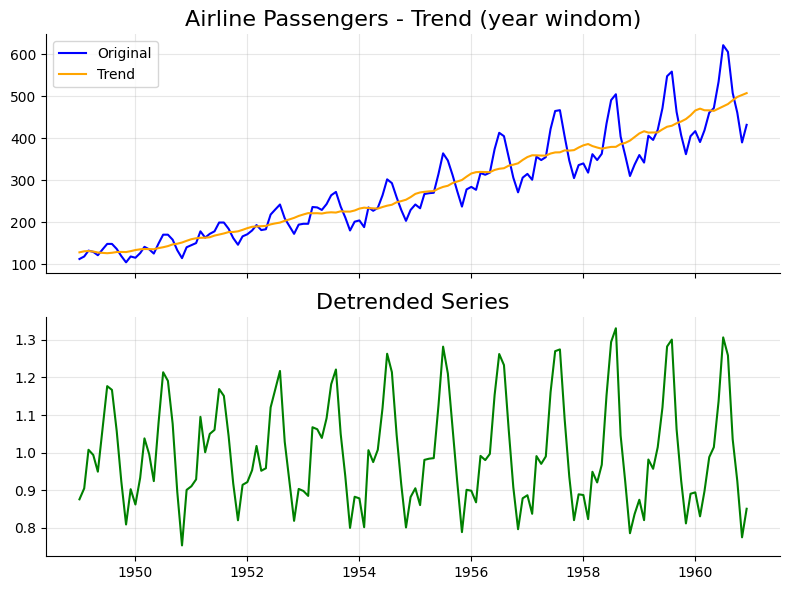

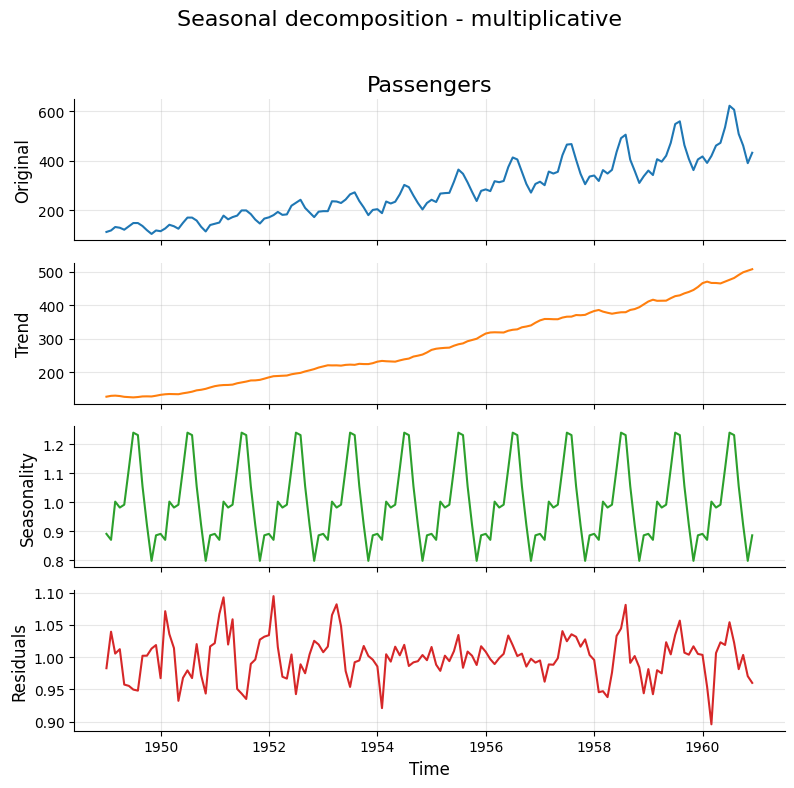

In [24]:
plot_ts_df_decomposition(
    passengers_df_mult,
    title_trend="Airline Passengers - Trend (year windom)",
    title_decompose="Seasonal decomposition - multiplicative",
)

### Python statsmodels decompose time series

Use built-in python statsmodels package method to make similar decomposition and visualizations

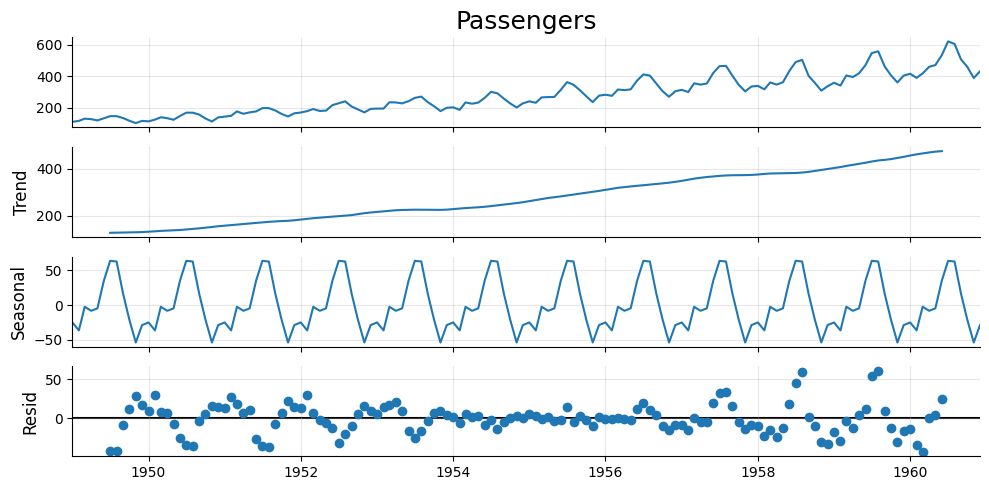

In [25]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition_plot_multi = seasonal_decompose(passengers_df['Passengers'],
                                              model='additive')
decomposition_plot_multi.plot()
plt.show()

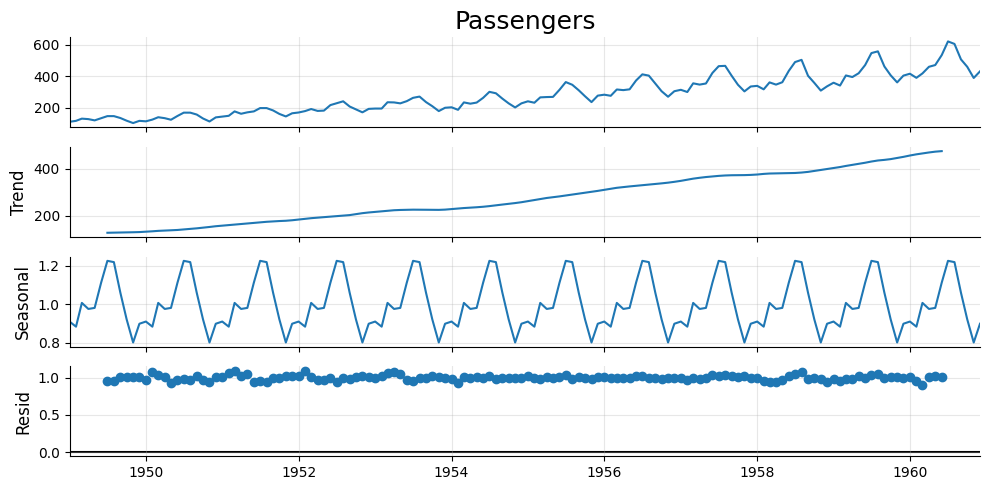

In [26]:
decomposition_plot_multi = seasonal_decompose(passengers_df['Passengers'],
                                              model='multiplicative')
decomposition_plot_multi.plot()
plt.show()

### Beer Dataset Decomposition

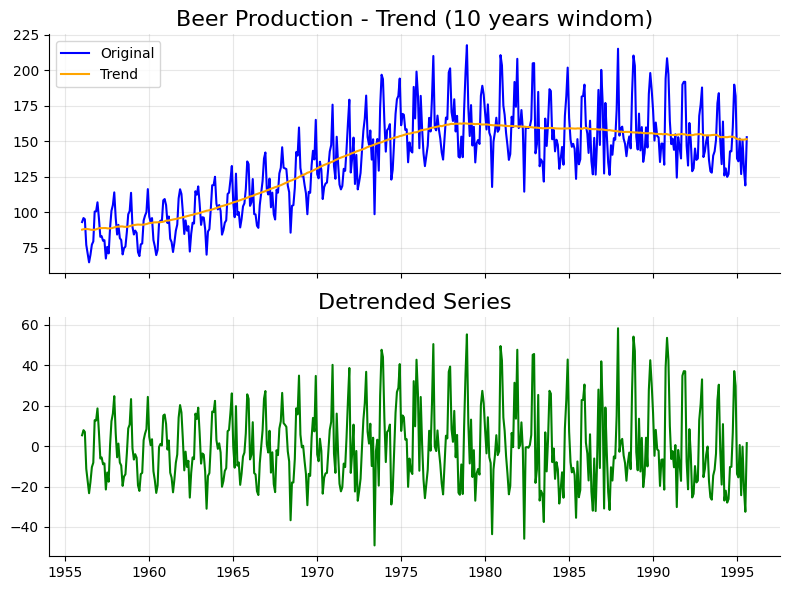

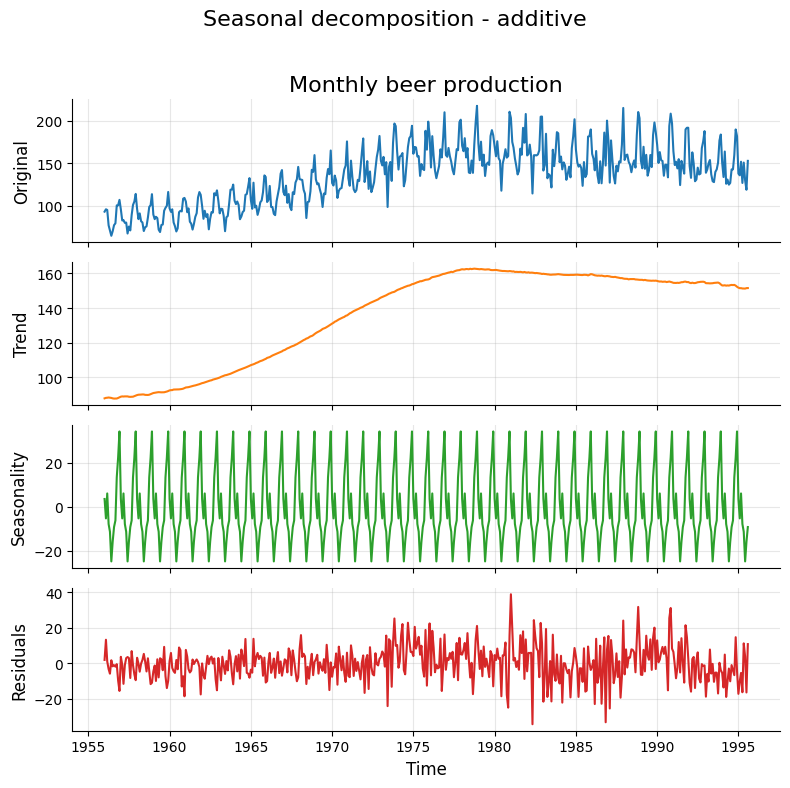

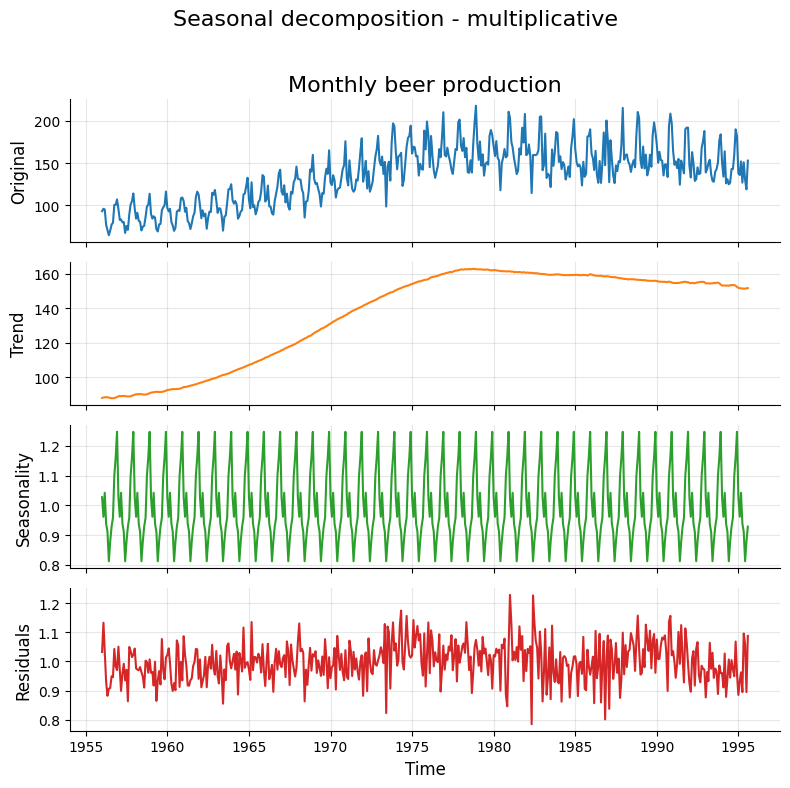

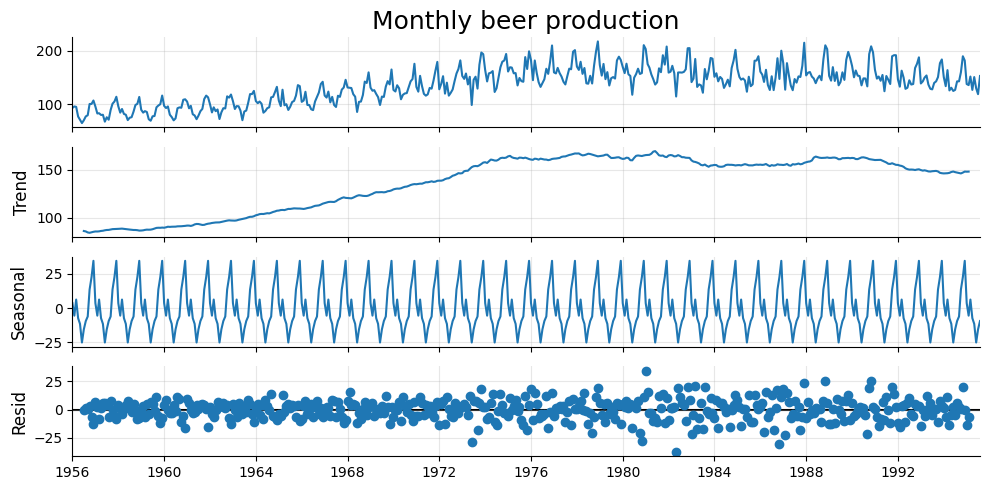

In [27]:
beer_df_add = create_ts_additive_df(beer_df, window=120, seasonal="month")
beer_df_mult = create_ts_multiplicative_df(beer_df, window=120, seasonal="month")

# additive
plot_ts_df_decomposition(
    beer_df_add,
    title_trend="Beer Production - Trend (10 years windom)",
    title_decompose="Seasonal decomposition - additive",
)

# multiiplicative
plot_ts_decompose(
    beer_df_mult,
    title="Seasonal decomposition - multiplicative",
)


# additive with statsmodels
decomposition_plot_multi = seasonal_decompose(beer_df["Monthly beer production"],
                                              model='additive')
decomposition_plot_multi.plot()
plt.show()

### Temperature Dataset Decompositions

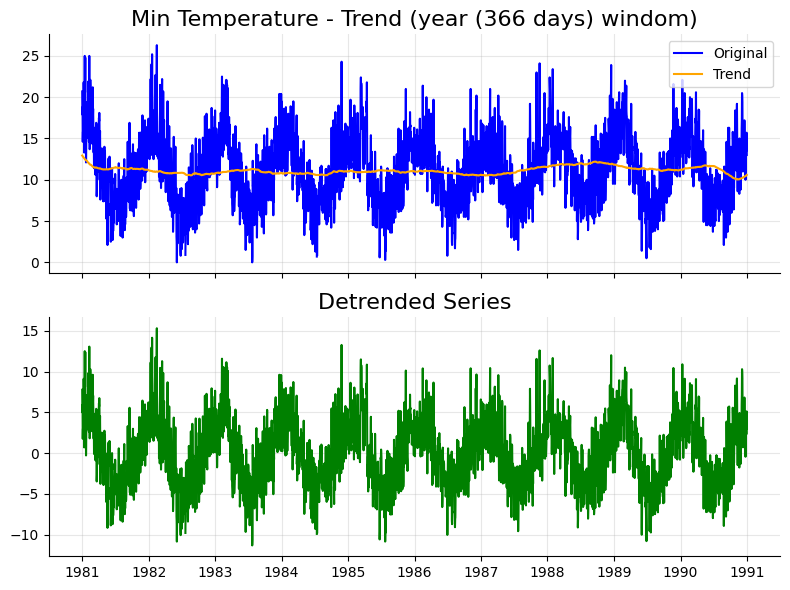

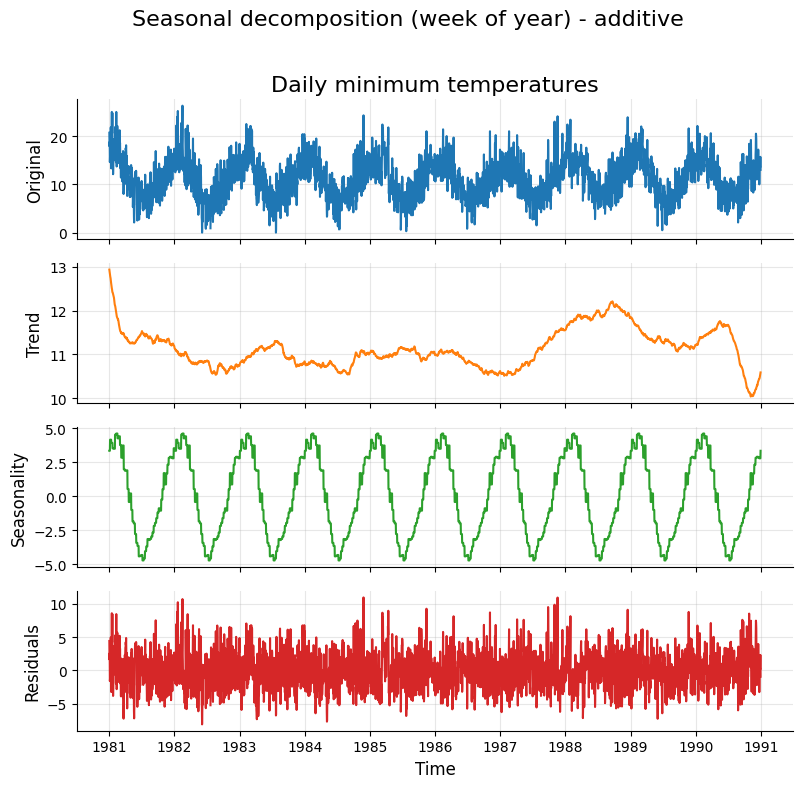

In [28]:
# here there is daily data - it make sense to experiment with "seasonal" param
temperature_df_add = create_ts_additive_df(temperature_df, window=366, seasonal="week") # "quarter" "month" "week" "dayofweek"

plot_ts_df_decomposition(
    temperature_df_add,
    title_trend="Min Temperature - Trend (year (366 days) windom)",
    title_decompose="Seasonal decomposition (week of year) - additive",
)

### Electric Production Dataset Decompositions

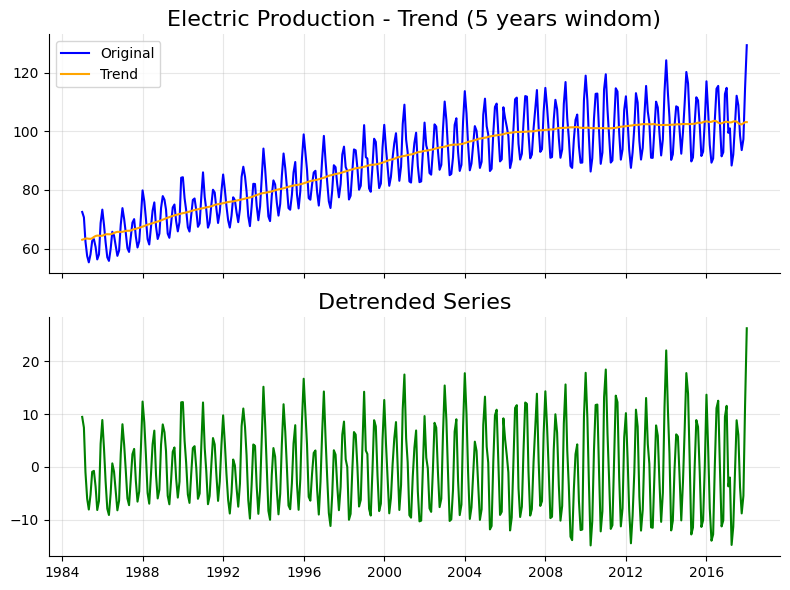

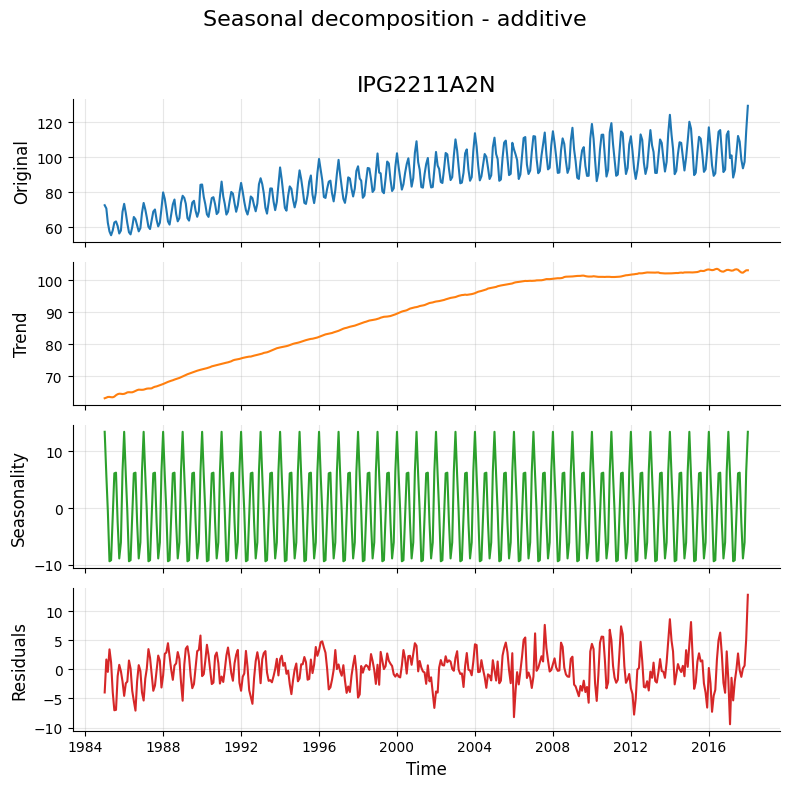

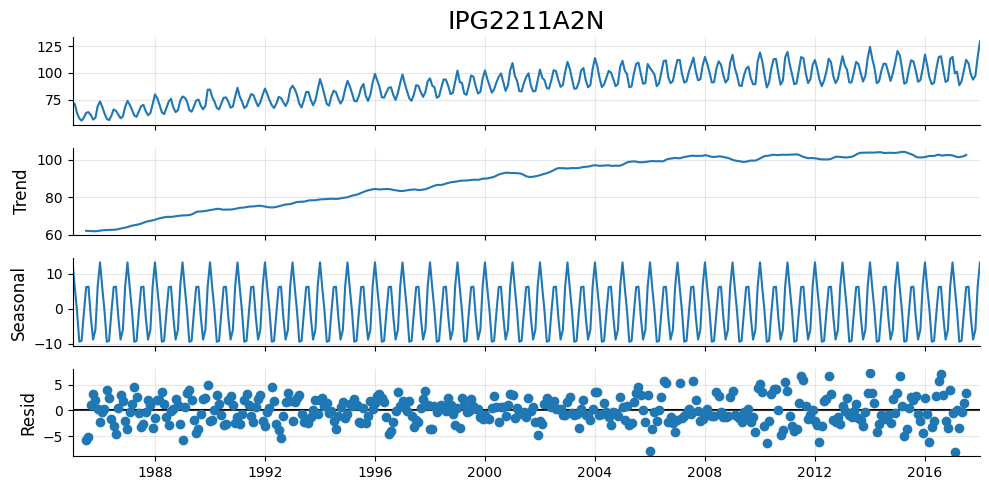

In [29]:
electric_df_add = create_ts_additive_df(electric_df, window=60, seasonal="month")

# additive
plot_ts_df_decomposition(
    electric_df_add,
    title_trend="Electric Production - Trend (5 years windom)",
    title_decompose="Seasonal decomposition - additive",
)

# additive with statsmodels
decomposition_plot_add = seasonal_decompose(electric_df["IPG2211A2N"],
                                              model='additive')
decomposition_plot_add.plot()
plt.show()